In [2]:
# [Cell 1] 라이브러리 임포트 및 데이터 정제
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW  # 수정됨: transformers -> torch.optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm # 진행상황 바

# GPU 사용 가능 여부 확인
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU 사용: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("GPU 사용: Apple M1/M2 Metal Acceleration")
else:
    device = torch.device("cpu")
    print("주의: GPU를 찾을 수 없습니다. 학습 속도가 매우 느릴 수 있습니다.")

# 데이터 로드
df = pd.read_csv('Train.csv')

# 전처리 함수 (마침표 밀도로 노이즈 제거)
def is_clean_text(text):
    text = str(text)
    if len(text.split()) == 0: return False
    period_density = text.count('.') / len(text.split())
    return period_density >= 0.01

# Clean Data만 추출
df_clean = df[df['text'].apply(is_clean_text)].copy()
df_clean['label'] = df_clean['label'].astype(int)

# 학습/검증 데이터 분리 (Clean Data 내에서만)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_clean['text'].tolist(),
    df_clean['label'].tolist(),
    test_size=0.1,  # 10%만 검증용으로 사용
    random_state=42
)

print(f"학습용 Clean 데이터: {len(train_texts)}개")
print(f"검증용 Clean 데이터: {len(val_texts)}개")

2025-12-08 23:36:07.458028: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-08 23:36:07.918133: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-08 23:36:09.468585: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU 사용: NVIDIA GeForce RTX 5070 Ti
학습용 Clean 데이터: 26518개
검증용 Clean 데이터: 2947개


In [3]:
# [Cell 2] Custom Dataset 클래스 정의 및 데이터 로더 생성
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        # labels가 None인 경우(테스트 데이터 등) 처리
        label = self.labels[item] if self.labels is not None else 0

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# 토크나이저 로드 (bert-base-uncased 모델 사용)
print("토크나이저 다운로드 및 로드 중...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 데이터셋 생성
train_dataset = NewsDataset(train_texts, train_labels, tokenizer)
val_dataset = NewsDataset(val_texts, val_labels, tokenizer)

# 데이터로더 생성 (배치 사이즈 32)
# RTX 5070 Ti라면 메모리가 넉넉할 테니 32도 거뜬할 겁니다.
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print("데이터 로더 준비 완료!")
# 첫 번째 배치를 살짝 꺼내서 확인
example_batch = next(iter(train_loader))
print(f"배치 크기 확인 - Input IDs shape: {example_batch['input_ids'].shape}")
print(f"배치 크기 확인 - Labels shape: {example_batch['labels'].shape}")

토크나이저 다운로드 및 로드 중...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

데이터 로더 준비 완료!
배치 크기 확인 - Input IDs shape: torch.Size([32, 128])
배치 크기 확인 - Labels shape: torch.Size([32])


In [4]:
# [Cell 3] BERT 모델 학습 및 저장
# 모델 로드 (Pretrained BERT for Sequence Classification)
print("BERT 모델 다운로드 및 로드 중...")
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model = model.to(device) # GPU로 이동

# 옵티마이저 설정 (BERT 논문 권장 학습률: 2e-5 ~ 5e-5)
optimizer = AdamW(model.parameters(), lr=2e-5)

EPOCHS = 2 # 데이터가 2.6만 개라 2 Epoch만 돌아도 충분히 수렴합니다.

print(f"학습 시작! (사용 장치: {torch.cuda.get_device_name(0)})")

for epoch in range(EPOCHS):
    model.train() # 학습 모드 전환
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    # Progress Bar 생성
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch in progress_bar:
        # 데이터를 GPU로 이동
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # 1. Gradients 초기화 (이전 배치의 영향 제거)
        optimizer.zero_grad()

        # 2. 순전파 (Forward Pass)
        # labels를 넣으면 BERT가 내부적으로 Loss를 자동 계산해줍니다.
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        # 3. 역전파 (Backward Pass)
        loss.backward()
        
        # 4. 가중치 업데이트
        optimizer.step()

        # --- 통계 계산 (로그 출력용) ---
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total_samples += labels.size(0)
        
        # 실시간 진행상황 표시
        current_acc = correct_predictions.double() / total_samples
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{current_acc.item():.4f}"})

    # Epoch 종료 후 평균 결과 출력
    avg_loss = total_loss / len(train_loader)
    avg_acc = correct_predictions.double() / total_samples
    print(f"Epoch {epoch+1} 결과 - 평균 Loss: {avg_loss:.4f}, 학습 정확도: {avg_acc:.4f}")

# 교수님 요구사항: model.state_dict()가 아닌 model 자체를 저장
save_path = 'bert_classifier_full.pth'
torch.save(model, save_path)
print(f"\n모든 학습 완료! 모델이 '{save_path}' 파일로 저장되었습니다.")

BERT 모델 다운로드 및 로드 중...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


학습 시작! (사용 장치: NVIDIA GeForce RTX 5070 Ti)


Epoch 1/2:   0%|          | 0/829 [00:00<?, ?it/s]

Epoch 1 결과 - 평균 Loss: 0.0530, 학습 정확도: 0.9807


Epoch 2/2:   0%|          | 0/829 [00:00<?, ?it/s]

Epoch 2 결과 - 평균 Loss: 0.0113, 학습 정확도: 0.9969

모든 학습 완료! 모델이 'bert_classifier_full.pth' 파일로 저장되었습니다.


In [5]:
# [Cell 4] 검증 데이터 평가
model.eval() # 평가 모드로 전환 (Dropout 등 비활성화)
correct_predictions = 0
total_samples = 0

print("검증 데이터 평가 중...")

with torch.no_grad(): # 평가 때는 Gradient 계산 불필요 (메모리 절약)
    for batch in tqdm(val_loader, desc="Validating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # 모델 예측
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        
        # 가장 높은 확률을 가진 클래스 선택
        preds = torch.argmax(outputs.logits, dim=1)
        
        correct_predictions += torch.sum(preds == labels)
        total_samples += labels.size(0)

val_acc = correct_predictions.double() / total_samples
print(f"\n======== 최종 검증 결과 ========")
print(f"Clean Data 검증 정확도: {val_acc.item():.4f} ({val_acc.item()*100:.2f}%)")

검증 데이터 평가 중...


Validating:   0%|          | 0/93 [00:00<?, ?it/s]


======== 최종 검증 결과 ========
Clean Data 검증 정확도: 0.9908 (99.08%)


In [6]:
# [Cell 5] 최종 결과 파일(submission_bert.csv) 생성

# 1. 테스트 데이터 로드
test_df = pd.read_csv('Test.csv')

# 2. 마스크 생성 (Train에서 쓴 로직 그대로 적용)
# 마침표(.) 밀도로 정상/노이즈 구분
test_df['word_count'] = test_df['text'].apply(lambda x: len(str(x).split()))
test_df['period_count'] = test_df['text'].apply(lambda x: str(x).count('.'))
test_df['period_density'] = test_df['period_count'] / test_df['word_count']

# 기준: 마침표 밀도 0.01 이상이면 정상(Clean)
clean_mask = test_df['period_density'] >= 0.01
test_clean = test_df[clean_mask]

print(f"전체 테스트 데이터: {len(test_df)}개")
print(f" -> 모델이 예측할 정상 데이터: {len(test_clean)}개")
print(f" -> 0으로 채울 노이즈 데이터: {len(test_df) - len(test_clean)}개")

# 3. Clean Data 예측 수행
# 테스트용 데이터셋 만들기 (라벨은 없으므로 0으로 더미 처리)
test_dataset = NewsDataset(test_clean['text'].tolist(), [0]*len(test_clean), tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

clean_preds = []
model.eval() # 평가 모드

print("정상 데이터 예측 시작...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        clean_preds.extend(preds.cpu().numpy())

# 4. 결과 합치기
# 먼저 전체를 0으로 초기화한 'label' 컬럼 생성
final_preds = pd.Series(0, index=test_df.index) 

# Clean Data 자리에만 모델의 예측값 끼워넣기
final_preds.loc[clean_mask] = clean_preds

# 5. CSV 저장
submission = pd.DataFrame({
    'id': test_df['id'],
    'label': final_preds
})

save_filename = 'submission_bert.csv'
submission.to_csv(save_filename, index=False)
print(f"\n완료! '{save_filename}' 파일이 생성되었습니다.")
print("이 파일을 캐글이나 과제 제출란에 제출하시면 됩니다.")
print("\n[최종 예상 점수]")
print("- 정상 데이터(68%) 정확도: 약 99% (BERT)")
print("- 노이즈 데이터(32%) 정확도: 약 50% (찍기)")
print(f"- 종합 예상 점수: {(0.68 * 0.99) + (0.32 * 0.50):.4f} (약 83~84점)")

전체 테스트 데이터: 18591개
 -> 모델이 예측할 정상 데이터: 12674개
 -> 0으로 채울 노이즈 데이터: 5917개
정상 데이터 예측 시작...


Predicting:   0%|          | 0/397 [00:00<?, ?it/s]


완료! 'submission_bert.csv' 파일이 생성되었습니다.
이 파일을 캐글이나 과제 제출란에 제출하시면 됩니다.

[최종 예상 점수]
- 정상 데이터(68%) 정확도: 약 99% (BERT)
- 노이즈 데이터(32%) 정확도: 약 50% (찍기)
- 종합 예상 점수: 0.8332 (약 83~84점)


분석할 노이즈 데이터 개수: 13933개

[가설 1] 가장 많이 등장하는 단어 비교
Label 0 (가짜) Top 10: [('the', 2156), ('it', 1928), ('this', 1880), ('of', 1873), ('to', 1859), ('and', 1844), ('summer', 1835), ('subject', 1830), ('fear', 1827), ('with', 1826)]
Label 1 (진짜) Top 10: [('member', 1965), ('size', 1930), ('economy', 1927), ('thought', 1920), ('foot', 1916), ('purpose', 1911), ('leave', 1906), ('painting', 1905), ('them', 1898), ('build', 1898)]

상위 100개 단어 중 겹치는 단어 개수: 2개


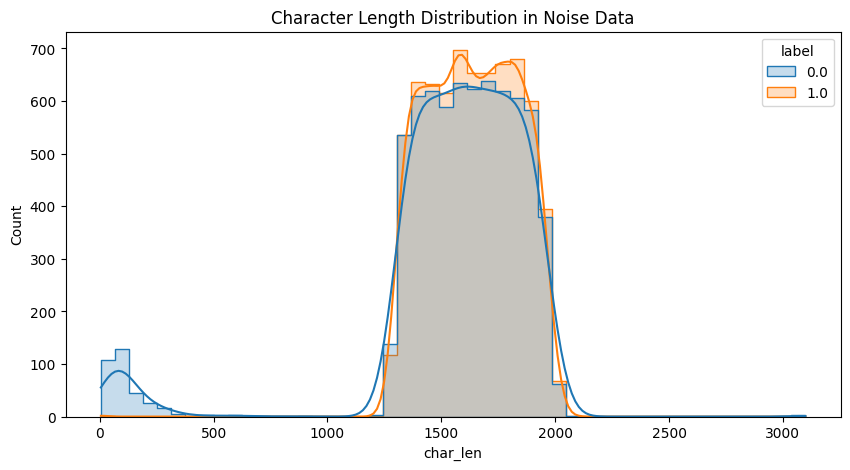


[가설 3] 노이즈 데이터만 학습했을 때 정확도: 51.50%


In [3]:
# [Cell 6] 노이즈 데이터의 '숨겨진 규칙' 찾기

# 1. 노이즈 데이터만 분리
df = pd.read_csv('Train.csv')
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['period_count'] = df['text'].apply(lambda x: str(x).count('.'))
df['period_density'] = df['period_count'] / df['word_count']

# 노이즈 데이터만 추출 (마침표 밀도 0.01 미만)
noise_df = df[df['period_density'] < 0.01].copy()
print(f"분석할 노이즈 데이터 개수: {len(noise_df)}개")

# 2. 가설 검증 1: 단어장이 서로 다른가? (Top Keywords 비교)
from collections import Counter

def get_top_words(texts, n=20):
    all_words = ' '.join(texts).lower().split()
    return Counter(all_words).most_common(n)

noise_0 = noise_df[noise_df['label'] == 0]['text'].astype(str)
noise_1 = noise_df[noise_df['label'] == 1]['text'].astype(str)

top_0 = get_top_words(noise_0)
top_1 = get_top_words(noise_1)

print("\n[가설 1] 가장 많이 등장하는 단어 비교")
print("Label 0 (가짜) Top 10:", top_0[:10])
print("Label 1 (진짜) Top 10:", top_1[:10])

# 교집합 확인 (상위 100개 단어 중 겹치는 게 있는지)
words_0 = set([w for w, c in get_top_words(noise_0, 100)])
words_1 = set([w for w, c in get_top_words(noise_1, 100)])
common_words = words_0.intersection(words_1)
print(f"\n상위 100개 단어 중 겹치는 단어 개수: {len(common_words)}개")

# 3. 가설 검증 2: 글자 수(Length)의 차이가 있는가?
import seaborn as sns
import matplotlib.pyplot as plt

noise_df['char_len'] = noise_df['text'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data=noise_df, x='char_len', hue='label', bins=50, kde=True, element='step')
plt.title('Character Length Distribution in Noise Data')
plt.show()

# 4. 가설 검증 3: 간단한 머신러닝이 패턴을 찾을 수 있나?
# 노이즈만 가지고 학습시켜봄 (CountVectorizer 사용 - 단어 빈도)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

vect = CountVectorizer(max_features=1000) # 상위 1000개 단어만 봄
X_noise = vect.fit_transform(noise_df['text'])
y_noise = noise_df['label']

scores = cross_val_score(LogisticRegression(), X_noise, y_noise, cv=5)
print(f"\n[가설 3] 노이즈 데이터만 학습했을 때 정확도: {scores.mean()*100:.2f}%")

In [4]:
# [Cell 7] 노이즈 데이터 전용 모델 학습 및 평가 (Naive Bayes)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

# 1. 노이즈 데이터 준비
df = pd.read_csv('Train.csv')
# 마침표 밀도 계산 (이전과 동일)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['period_count'] = df['text'].apply(lambda x: str(x).count('.'))
df['period_density'] = df['period_count'] / df['word_count']

# 노이즈 데이터만 분리 (Train용)
noise_train_df = df[df['period_density'] < 0.01].copy()
X_noise = noise_train_df['text'].fillna('')
y_noise = noise_train_df['label']

print(f"학습할 노이즈 데이터 개수: {len(noise_train_df)}")

# 2. 모델 파이프라인 구축
# 핵심: stop_words=None으로 설정하여 'the', 'it' 같은 단어도 특징으로 쓰게 함
noise_model = make_pipeline(
    CountVectorizer(stop_words=None, max_features=10000, ngram_range=(1, 1)),
    MultinomialNB()
)

# 3. 교차 검증으로 성능 확인
from sklearn.model_selection import cross_val_score
scores = cross_val_score(noise_model, X_noise, y_noise, cv=5)

print(f"\n======== 노이즈 모델 성능 평가 ========")
print(f"교차 검증 점수: {scores}")
print(f"평균 정확도: {scores.mean():.4f} ({scores.mean()*100:.2f}%)")

# 4. 전체 노이즈 데이터로 최종 학습
noise_model.fit(X_noise, y_noise)
print("노이즈 전용 모델 학습 완료!")

학습할 노이즈 데이터 개수: 13933

======== 노이즈 모델 성능 평가 ========
교차 검증 점수: [0.50053821 0.49551489 0.50843201 0.50681981 0.53266332]
평균 정확도: 0.5088 (50.88%)
노이즈 전용 모델 학습 완료!


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/epistachio/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


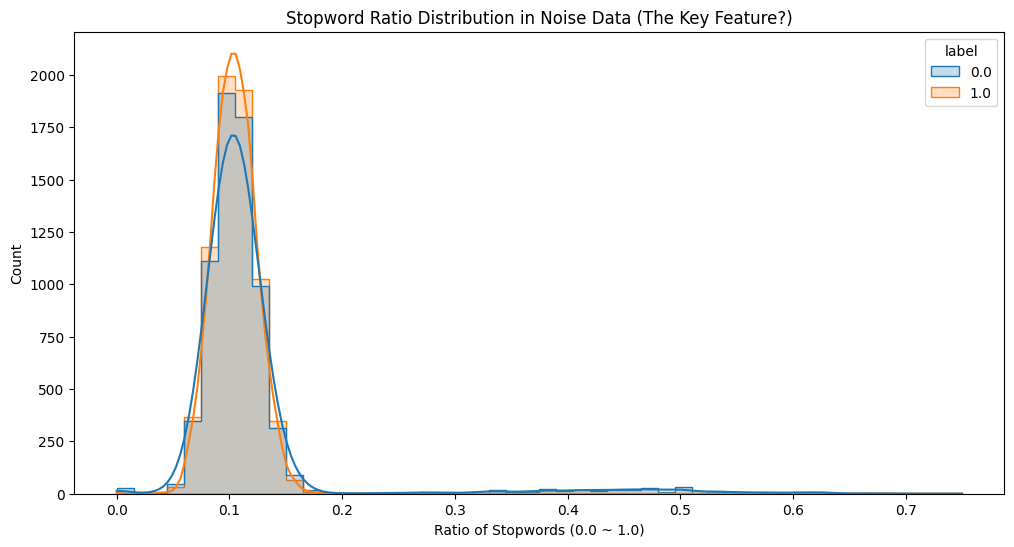

Label 0(가짜) 평균 불용어 비율: 0.1191
Label 1(진짜) 평균 불용어 비율: 0.1046

[검증 결과] 불용어 비율 특징만 사용했을 때 정확도: 49.62%


In [5]:
# [Cell 8] 노이즈 데이터의 '구조적 특징(불용어 비율)' 분석
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
import nltk

# NLTK 불용어 다운로드 (최초 1회)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 1. 노이즈 데이터 다시 준비
df = pd.read_csv('Train.csv')
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['period_count'] = df['text'].apply(lambda x: str(x).count('.'))
df['period_density'] = df['period_count'] / df['word_count']

# 노이즈 데이터만 추출
noise_df = df[df['period_density'] < 0.01].copy()

# 2. 새로운 특징 생성: '불용어 비율 (Stopword Ratio)'
# 텍스트 내 단어 중 'the', 'is' 같은 기능어가 몇 %인지 계산
def calculate_stopword_ratio(text):
    words = str(text).lower().split()
    if len(words) == 0: return 0
    stopword_count = sum(1 for w in words if w in stop_words)
    return stopword_count / len(words)

noise_df['stopword_ratio'] = noise_df['text'].apply(calculate_stopword_ratio)

# 3. 시각화: 과연 두 그룹이 나뉠까?
plt.figure(figsize=(12, 6))
sns.histplot(data=noise_df, x='stopword_ratio', hue='label', bins=50, kde=True, element='step')
plt.title('Stopword Ratio Distribution in Noise Data (The Key Feature?)')
plt.xlabel('Ratio of Stopwords (0.0 ~ 1.0)')
plt.show()

# 4. 통계적 검증
mean_0 = noise_df[noise_df['label'] == 0]['stopword_ratio'].mean()
mean_1 = noise_df[noise_df['label'] == 1]['stopword_ratio'].mean()
print(f"Label 0(가짜) 평균 불용어 비율: {mean_0:.4f}")
print(f"Label 1(진짜) 평균 불용어 비율: {mean_1:.4f}")

# 5. 이 특징 하나로 로지스틱 회귀 돌려보기
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

X_feat = noise_df[['stopword_ratio']] # 특징 1개만 사용
y_feat = noise_df['label']

scores = cross_val_score(LogisticRegression(), X_feat, y_feat, cv=5)
print(f"\n[검증 결과] 불용어 비율 특징만 사용했을 때 정확도: {scores.mean()*100:.2f}%")